# Shrinking body size and rising prey scarcity in Atlantic Forest birds

over three decades of climate change

Eduardo S.A. Santos [](https://orcid.org/0000-0002-0434-3655) (Collaboration for Open Science and Synthesis in Ecology and Evolution, Department of Biological Sciences, University of Alberta, Edmonton, AB, T6G 2E9, Canada)  
João C.T. Menezes [](https://orcid.org/0000-0003-4156-2934) (Organismic and Evolutionary Biology Graduate Program, University of Massachusetts Amherst, Amherst, MA, 01003, USA)  
Gustavo Burin [](https://orcid.org/0000-0001-7851-0666) (Department of Biological and Environmental Sciences, University of Gothenburg, Sweden)  
June 11, 2026

Declining body size has been proposed as a third universal response of animals to climate warming, alongside shifts in phenology and geographic range. Whether this response is widespread in the species-rich avifaunas of the tropics, and whether it tracks temperature directly or the availability of food, remains poorly resolved. Here we use the ATLANTIC BIRD TRAITS dataset to assemble morphological measurements for passerine bird species sampled across the Brazilian Atlantic Forest between 1990 and 2018, and analyse temporal trends in wing length and bill width with Bayesian phylogenetic multilevel models that account for sex, latitude, repeated sampling of species, and phylogenetic non-independence. Across species, wing length declined over the 28-year period — a decline robust to phylogenetic uncertainty and to the choice of phylogeny — whereas bill width showed no comparable directional change. The among-individual variability of wing length increased in the most recently sampled birds, consistent with a population responding heterogeneously to a changing environment. Over the same region and period, the abundance of arthropod prey declined steeply in forested biomes; the decline strengthened when ants were included as prey — justified by documented opportunistic predation of flying ant reproductives by passerines — and remained substantial under the conservative ant-exclusion assumption. Our findings link a regional collapse in invertebrate prey to morphological change in their avian predators, and illustrate why distinguishing thermoregulatory from trophic drivers of body-size change requires datasets that capture both climate and resources.

In [ ]:
arth    <- readRDS("../Analysis/arthropod_estimates.rds")
diet    <- readRDS("../Analysis/diet_interaction_results.rds")
dat_sum <- readRDS("../Analysis/data_summary.rds")

# helper: pull one number from a pooled-results data frame by parameter name
.pe <- function(df, par, col) round(df[[col]][df$par == par], 2)

# diet interaction
int_A   <- diet$model_A_pooled
yr_A    <- .pe(int_A, "b_scaled_yr",              "estimate")
int_est <- .pe(int_A, "b_scaled_yr:diet_inv_std", "estimate")
int_lo  <- .pe(int_A, "b_scaled_yr:diet_inv_std", "lower")
int_hi  <- .pe(int_A, "b_scaled_yr:diet_inv_std", "upper")
slope_low  <- round(yr_A - int_est, 2)   # diet −1 SD
slope_high <- round(yr_A + int_est, 2)   # diet +1 SD

# sensitivity threshold results (Tier 1)
sens <- tryCatch(readRDS("../Analysis/sensitivity_thresholds_tier1.rds"),
                 error = function(e) NULL)
if (!is.null(sens)) {
  n_sens_total     <- nrow(sens)
  n_sens_sexfilter <- sum(sens$sex_filter)
  n_neg_sexfilter  <- sum(sens$sex_filter  & sens$b_yr_hi < 0)
  n_neg_nosex      <- sum(!sens$sex_filter & sens$b_yr_hi < 0)
}

Two of the most widely documented responses of organisms to climate warming are shifts in phenology and in geographic range \[@parmesan_globally_2003\]. A third response — a reduction in body size — is increasingly reported across taxa and has been proposed as a general consequence of warming \[@gardner_declining_2011; @sheridan_shrinking_2011; @teplitsky_climate_2014\]. The expectation follows from Bergmann’s rule, the ecogeographical pattern whereby endotherms are smaller in warmer climates because a higher surface-area-to-volume ratio aids heat dissipation \[@bergmann1847; @mayr1956; @ashton2002a\]. Body-size reductions under warming may arise through temperature-dependent thermoregulatory mechanisms or through temperature-independent declines in food availability that constrain growth \[@gardner_declining_2011; @schmidt_concomitant_2005; @teplitsky_bergmanns_2008\]. Disentangling these pathways requires data on both climate and resources, which are rarely available together, especially in the tropics. Here we show that, across 89 passerine species sampled in the Brazilian Atlantic Forest between 1990 and 2018, wing length declined over time — though modestly and heterogeneously among species — while bill width did not, and the among-individual variability of wing length rose in recently sampled birds. Over the same region and interval, the abundance of arthropod prey fell steeply. These results connect a regional decline in invertebrate prey to morphological change in their avian predators and underscore that body-size responses to climate change need not reflect thermoregulation alone \[@ozgul2009; @weeks2020; @ryding2024\].

# Results and discussion

## Three decades of avian morphology in the Atlantic Forest

We drew morphological measurements from the ATLANTIC BIRD TRAITS dataset \[@rodrigues_atlantic_2019\], in which passerines account for 82% of all records (60,066 of 72,483 entries). Restricting the data to adult birds (n = 43,149) recorded between 1990 and 2018 yielded 40,183 passerine measurements. We retained species with at least 30 records; after removing individuals of unknown sex, requiring a sampling span of at least 5 years per species, and keeping only records inside a 20-km buffer of the Atlantic Forest domain, our analytical sample comprised 89 passerine species (@fig-map). We used wing length

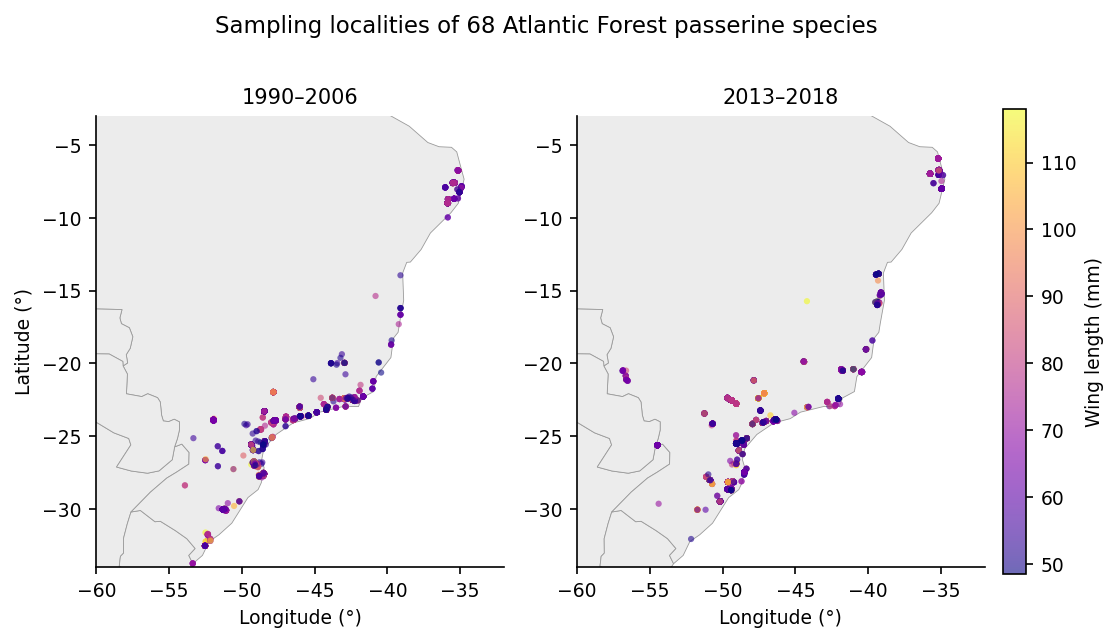{#fig-map }

1.  as our index of body size because it had the fewest missing values among the available traits; assuming bilateral symmetry, we combined left, right, and unspecified wing measurements into a single variable to minimise missing data. Bill width (mm) provided a complementary trait expected to track diet rather than thermoregulation.

## Wing length declined over time

We modelled wing length with Bayesian phylogenetic multilevel models including sex and latitude as fixed effects, a species-level random intercept structured by a phylogenetic covariance matrix derived from the complete avian phylogeny of @mctavish2025tree, and species-specific random intercepts and slopes for year; we propagated phylogenetic uncertainty across 50 trees and pooled estimates with Rubin’s rules (Methods). Using the coalesced wing-length variable, wing length decreased over time (standardized year effect β = −0.66, 95% CI −1.05 to −0.28, excluding zero), males were larger than females (β = 2.56 mm, 95% CI 2.35 to 2.77), and wing length declined with our latitude index (β = −0.43, 95% CI −0.61 to −0.24); the analysis used 15332 records across 89 species. Phylogeny accounted for the overwhelming majority of among-species variance (proportion = 0.95, 95% CI 0.94 to 0.96), as expected for a conserved morphological trait.

The temporal decline excluded zero and was robust to phylogenetic uncertainty and to the updated phylogeny (@fig-wingtrend). A complementary, model-free comparison of species means between the first (1990–2006) and last (2013–2018) quartiles of the record showed the same direction (@fig-trends): 47 of 67 species had smaller mean wing length in the later period, and 20 had larger.

![Wing length of 89 Atlantic Forest passerines against year of sampling, 1990–2018. Shading shows the density of individual records (log scale); the line is the model-estimated population trend with its 95% interval \[UPDATE: rerun atlantic_parallel.R\].](attachment:images/fig-wingtrend.png){#fig-wingtrend }

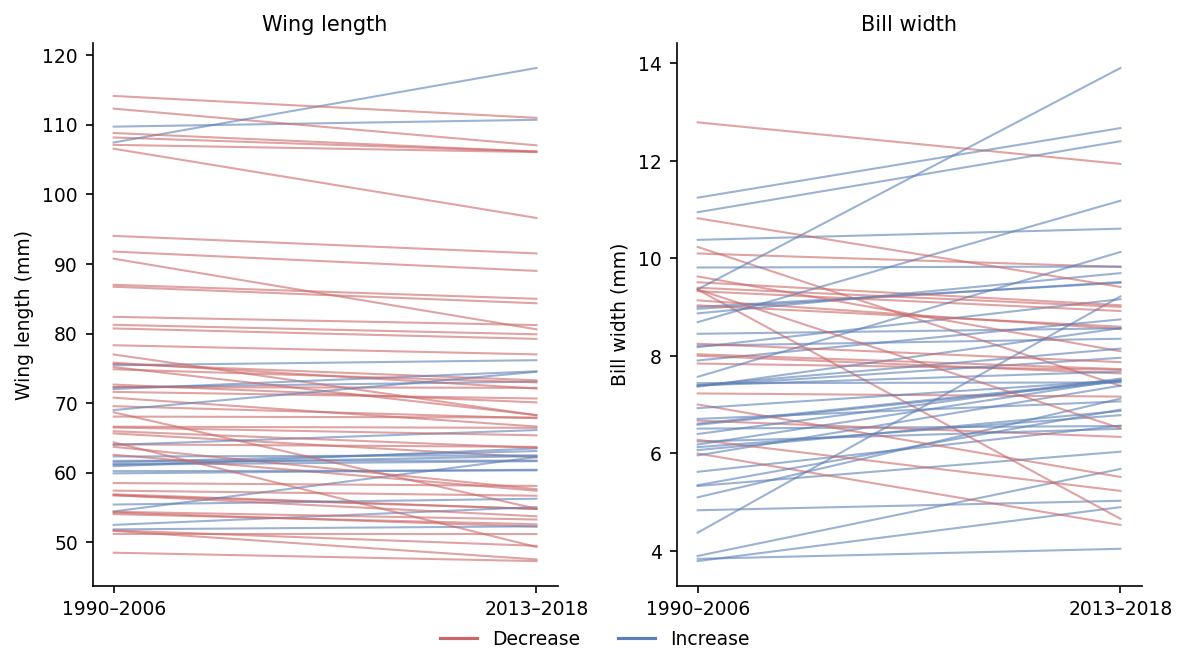{#fig-trends }

Although now statistically clear and robust to phylogenetic uncertainty, the decline remains modest in magnitude and, as we show next, is accompanied by rising among-individual variability. A body-size response that is real but small and increasingly variable is more compatible with a resource-mediated, plastic mechanism than with a uniform thermoregulatory adjustment.

## Bill width did not track time, and trait variability rose

In contrast to wing length, bill width showed no directional change over time (β = 0.11, 95% CI −0.03 to 0.26; N = 4,223) and a weaker phylogenetic signal (proportion = 0.55, 95% CI 0.49 to 0.62); like wing length, it declined with our latitude index (β = −0.38, 95% CI −0.47 to −0.28). The quartile comparison again agreed in direction, with most species (38 of 60) showing wider mean bills in the later period.

To ask whether birds became not just smaller but more variable, we computed the log coefficient-of-variation ratio (lnCVR) between the late and early periods for each species and combined them in random-effects meta-analyses \[@nakagawa2015metaanalysis\]. Among-individual variability in wing length increased significantly in the recent period (lnCVR = 0.25, 95% CI 0.10 to 0.39; k = 63; I² = 94.6%; @fig-variability, left), whereas variability in bill width did not change detectably (lnCVR = −0.04, 95% CI −0.24 to 0.16; k = 53; @fig-variability, right). Rising phenotypic variability in the trait that also declined in mean is consistent with a population in which individuals respond unequally to a deteriorating environment, rather than with a coordinated shift toward a new optimum.

![Forest plots of the log coefficient-of-variation ratio (lnCVR) between the late and early periods, for (left) wing length and (right) bill width, one estimate per species (95% CI), with the random-effects meta-analytic mean (vertical line, shaded 95% CI). Positive values indicate greater among-individual variability in recently sampled birds; intervals use the corrected standard errors.](attachment:images/fig-variability.png){#fig-variability }

## Arthropod prey declined steeply over the same region and period

If body-size change in these largely insectivorous birds is mediated by food rather than temperature, the abundance of their invertebrate prey should have declined over the study period. Using the PREDICTS database \[@hudson2017database\], we modelled the abundance of Insecta and Arachnida in forested biomes across South America with negative-binomial models that included sampling effort as an offset (Methods). Although ants are not a core dietary component of most passerines, some species opportunistically predate flying ant reproductives (alates) during nuptial flights \[@helms_are_2016\], so our main model retains Formicidae; the ant-exclusion variant serves as a conservative lower bound. Arthropod abundance declined markedly with time in the main model (standardized year effect β = -1.4, 95% CrI -1.46 to -1.34; N = 63150 records), equivalent to a multiplicative change of 0.25 (95% CrI 0.23 to 0.26) per standard-deviation increase in year (@fig-arthropods). Excluding ants gave a shallower but still substantial decline (β = -1.22, 95% CrI -1.29 to -1.15; N = 53139), confirming that including ants does not inflate the signal — if anything, their decline is steeper than the broader community. The arthropod prey collapse is therefore robust to the treatment of ants and restricted to forested habitats.

![Abundance of Insecta and Arachnida in forested biomes across South America (PREDICTS database) against time, with the fitted negative-binomial trend and 95% credible interval. Ants (Formicidae) are included in the main model; the ant-exclusion sensitivity gave a shallower but qualitatively identical decline. *Placeholder pending regeneration from the analysis.*](attachment:images/fig-arthropods.png){#fig-arthropods }

## The temporal decline is not amplified in more insectivorous species

If arthropod scarcity is the proximate driver of body-size change, species more reliant on invertebrate prey should show steeper temporal trends in wing length. We tested this by adding an interaction between scaled year and each species’ standardised proportion of invertebrates in their diet (Diet-Inv from EltonTraits \[@wilman2014eltontraits\]; Methods). Of the 89 species in the main analysis, 76 had EltonTraits diet data and were retained; the 13 species without diet information were excluded from this model only.

The interaction was positive and its 95% credible interval excluded zero (β = 0.52, 95% CI 0.18 to 0.87), meaning that species with *less* invertebrate diet declined *more* steeply — the opposite of the food-limitation prediction. Projecting the year slope across the diet gradient, species one standard deviation below the mean in invertebrate diet proportion had an implied slope of -1.25 mm per SD-year, compared with -0.21 mm per SD-year for species one standard deviation above the mean (@fig-dietinteraction). The overall year effect remained negative and excluded zero (β = -0.73; consistent with the main analysis), confirming the decline is real across diet types; it is simply not concentrated in the most insectivorous species.

![Predicted wing-length year trend as a function of invertebrate diet proportion (standardised), from the phylogenetic interaction model. Lines show the predicted trajectory for females at mean latitude; shading is the 95% credible interval. The positive interaction indicates that species with less invertebrate diet show the steeper temporal decline.](attachment:images/diet_interaction_plot.png){#fig-dietinteraction }

## Inclusion threshold sensitivity

Our main analysis required species to have at least 30 records and a minimum sampling span of 5 years; individuals of unknown sex were excluded. To assess whether the year → wing-length result is an artefact of these choices, we refitted the model across a grid of 18 threshold combinations spanning three minimum-record thresholds (30, 40, and 50), three minimum-span thresholds (5, 8, and 10 years), and with or without the unknown-sex filter (Supplementary Fig. S1). The year effect remained negative and its 95% credible interval excluded zero in 9 of 9 combinations that retained the sex filter. Dropping the sex filter consistently widened credible intervals to overlap zero in 6 of 9 combinations, indicating that unknown-sex records add noise rather than biological signal and that the sex-filter exclusion is a quality-control step rather than an arbitrary restriction. Across all threshold combinations retaining the sex filter, the negative year effect on wing length was consistent in direction and magnitude, supporting the conclusion that the reported decline is not an artefact of specific inclusion criteria.

## Synthesis

Our results present a coherent but nuanced picture. Wing length declined modestly and heterogeneously across 89 Atlantic Forest passerines over 28 years, bill width did not change directionally, and among-individual variability in wing length rose — consistent with a population responding unevenly to a deteriorating environment rather than shifting uniformly toward a new optimum. Over the same region and period, arthropod prey abundance fell steeply, and this collapse was robust to how ants were treated and to the exclusion of open-habitat records.

The diet-interaction analysis, however, complicates a simple food-limitation interpretation. The temporal decline in wing length was not steeper in species most reliant on invertebrate prey; if anything it was weaker, with less insectivorous species declining more. This argues against a direct, diet-mediated pathway from arthropod scarcity to body-size loss. A more likely reconciliation is that both the arthropod decline and the morphological change are downstream consequences of the same regional warming, rather than standing in a direct cause-and-effect relationship: temperature shapes body size through thermoregulatory mechanisms consistent with Bergmann’s rule, while simultaneously suppressing arthropod populations through independent phenological and metabolic pathways \[@gardner_declining_2011; @dirzo2014defaunation\]. Strictly insectivorous species may additionally buffer size loss through behavioural compensation — increased foraging effort or prey switching — in ways that facultative omnivores and frugivores cannot \[@robb2008food\].

We caution that our design links birds and prey at the level of shared region and period rather than through a joint model of individual birds and their local food supply. A more powerful test would track arthropod abundance at the scale of individual capture localities and model it as a time-varying predictor of body size; we identify this as the priority next step. Even so, the co-occurrence of a regional prey collapse and morphological change in avian predators across three decades highlights an under-appreciated dimension of climate-change impacts on tropical biodiversity — one in which warming may simultaneously reshape the phenotypes of predators and diminish the resources that sustain them.

# Methods

## Morphological data and inclusion criteria

Bird morphological data were obtained from the ATLANTIC BIRD TRAITS dataset \[@rodrigues_atlantic_2019\], a compilation of measurements from the Atlantic forests of South America. We restricted records to the order Passeriformes; to individuals aged as adults at collection; to records dated 1990–2018; and to localities within a 20-km buffer of the Atlantic Forest domain. We retained only species with at least 30 records and a sampling span of at least 5 years, and excluded individuals of unknown sex. These criteria yielded 89 species. Species binomials were reconciled to the taxonomy of the phylogeny by recoding six names (e.g., *Ceratopipra rubrocapilla* → *Pipra rubrocapilla*; *Myiothlypis leucoblephara* → *Basileuterus leucoblepharus*).

Wing length was chosen as the body-size index because it had the least missing data among candidate traits. We coalesced right-wing, left-wing, and unspecified wing measurements (in that order of priority) into a single variable, assuming bilateral symmetry, to reduce missingness. Bill width was analysed as a complementary trait. Year and latitude were mean-centred and scaled to unit standard deviation prior to modelling; latitude was multiplied by −1 before scaling so that larger values denote more southerly (and typically cooler) localities. Diet categories were assigned from EltonTraits \[@wilman2014eltontraits\]; the analytical species are overwhelmingly invertebrate-consuming, and only a small number have no invertebrate component in their diet.

## Climate context

We did not estimate a temporal temperature or precipitation trend from the morphological dataset. The `Annual_mean_temperature` and `Annual_rainfall` fields in ATLANTIC BIRD TRAITS are static long-term climatologies attached to each locality rather than conditions measured at the time of capture: across the sampled localities, 97% carry a single temperature value regardless of how many years they were sampled, so any apparent change over time reflects which localities were visited when, not climatic change. We therefore treat warming over the study region and period as established by independent climatological records and the broader literature \[@gardner_declining_2011; @teplitsky_climate_2014\].

To move beyond year as a proxy for climate, we additionally link each record to **time-resolved** monthly temperature from WorldClim historical weather (CRU-TS 4.09 downscaled with WorldClim 2.1; @fick2017worldclim; @harris2020crudata) at the record’s coordinates and year of capture (`climate_extraction.R`). This yields the actual temperature experienced by each individual, allowing body size to be modelled directly against climate.
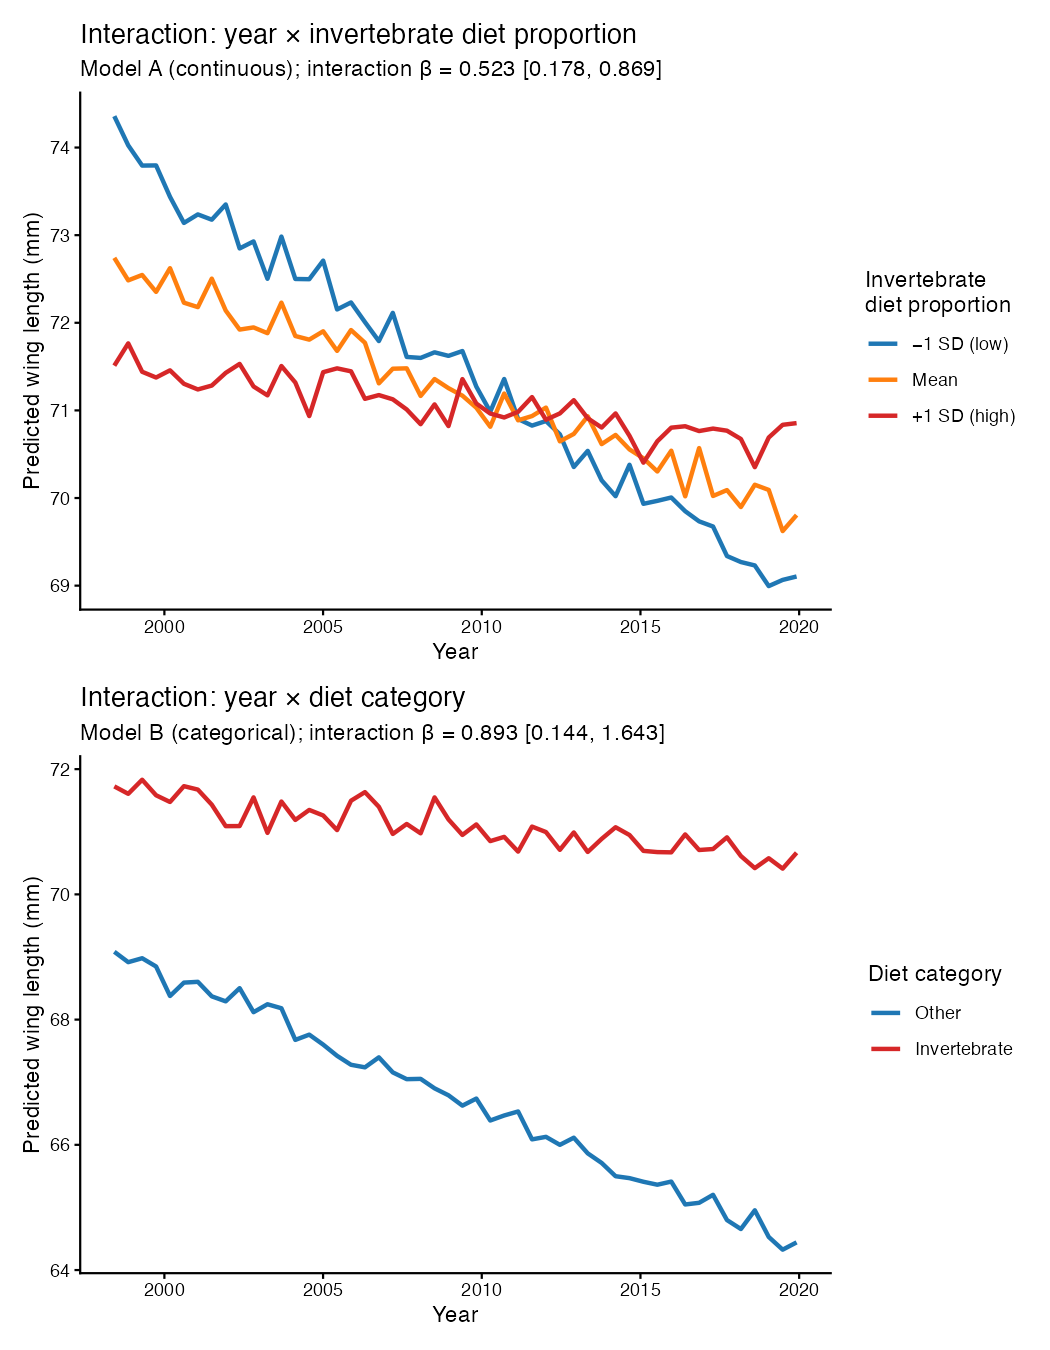
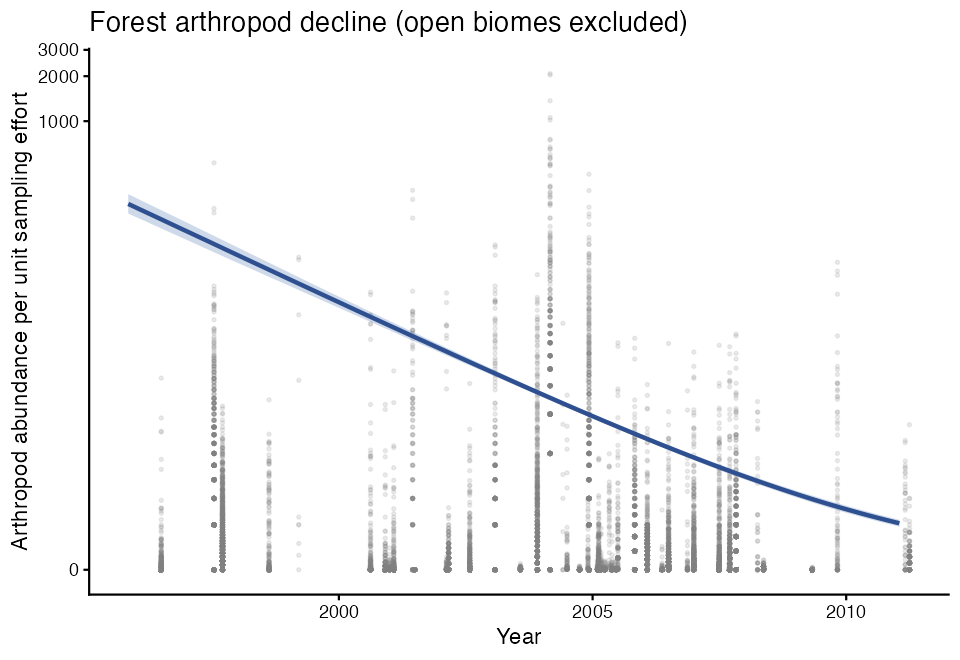
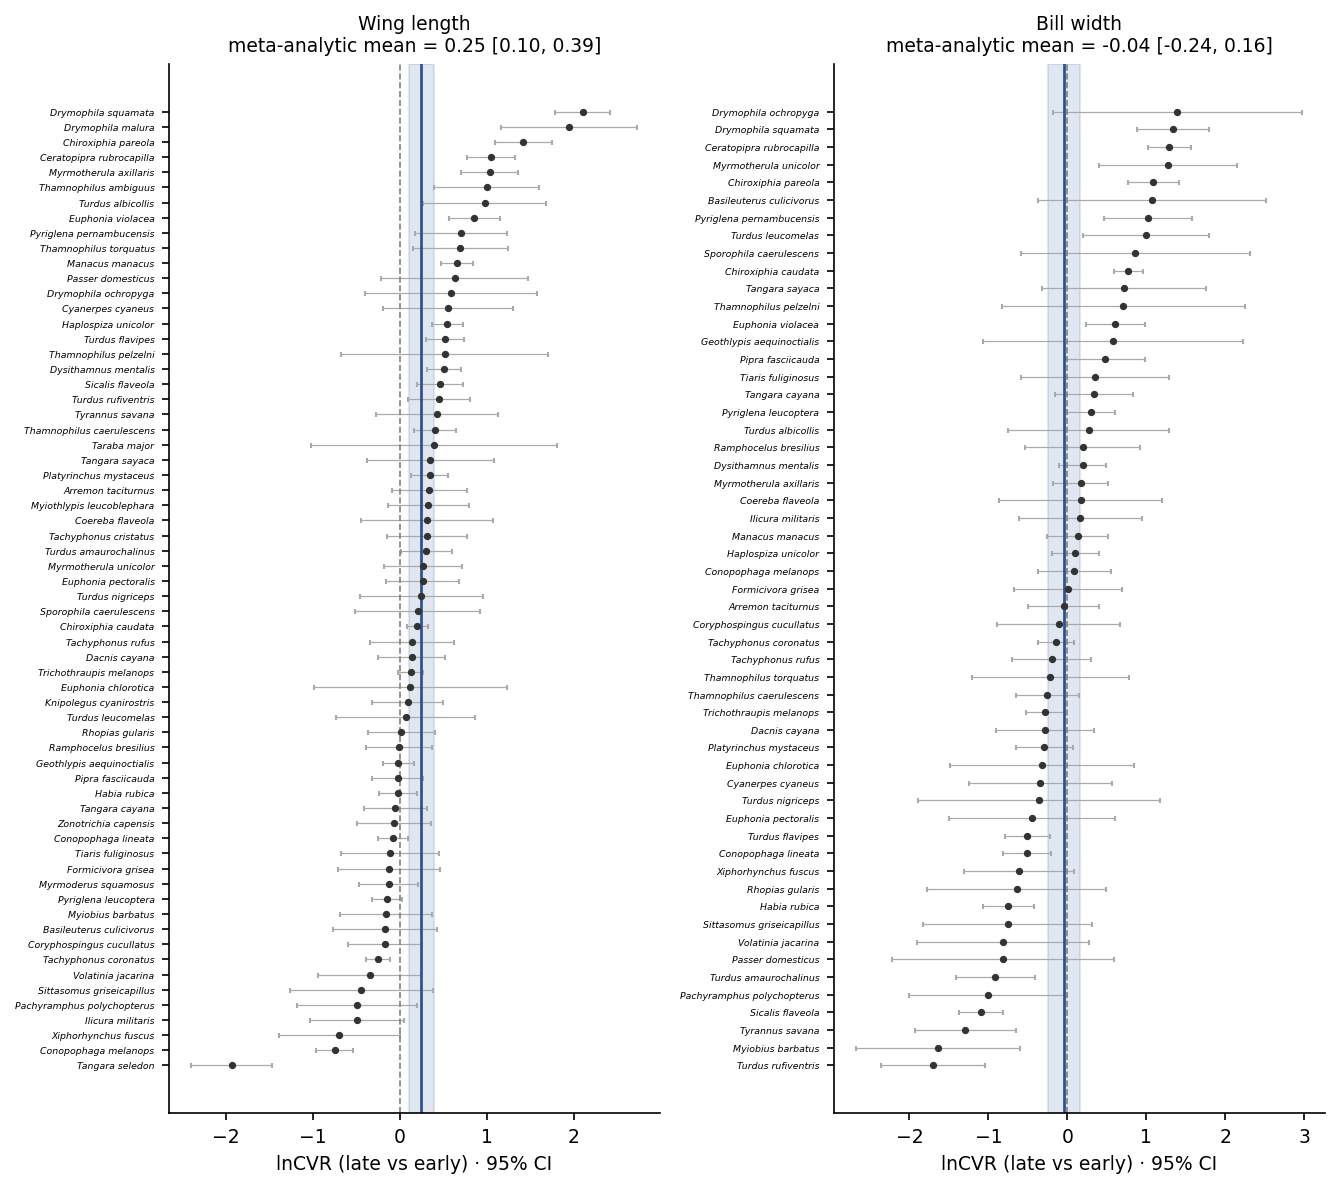
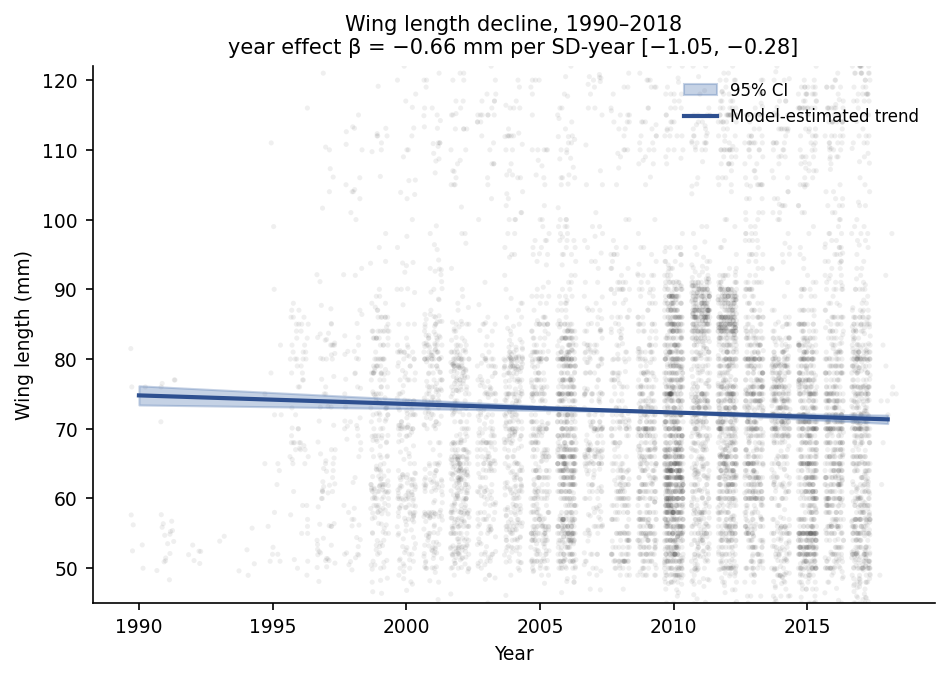

## Phylogeny

We obtained species-level trees from the complete and dynamic avian phylogeny of @mctavish2025tree, accessed through the `clootl` R package \[@miller2026clootl\], which supersedes the earlier @jetz2012global BirdTree (Hackett-backbone) trees used in initial analyses. We retrieved the trees through the `prepR4pcm` package \[@nakagawa2026prepr4pcm\] and used its four-stage matching cascade (exact, normalised, synonym, and fuzzy matching) to reconcile our species names to the phylogeny’s tip labels, auditing every match so that no species was silently dropped, before aligning the trait data to the pruned tree. We drew 50 trees from a pool of 100 to represent phylogenetic uncertainty. For models conditioned on a single topology, we constructed a phylogenetic covariance matrix by inverting the matrix returned by `MCMCglmm::inverseA` (scaled, tips only). To propagate phylogenetic uncertainty, we refitted the model across all 50 trees and pooled estimates across trees using Rubin’s rules \[@nakagawa2019rubin\], reporting Wald–Rubin 95% intervals, rather than naively concatenating posterior draws.

## Body-size and bill-width models

We fitted Bayesian multilevel models in `brms` \[@burkner2017brms\] with Stan. For wing length: wing length ~ 1 + sex + scaled year + scaled latitude + (1 + scaled year \|\| species) + (1 \| binomial), where the `(1 | binomial)` term carried the phylogenetic covariance matrix, the double-bar species term estimated uncorrelated species intercepts and year slopes, sex was included as a fixed effect, and an analogous model for bill width omitted sex. Priors were weakly informative: Normal(71, 15) and Normal(9, 2.5) on the wing- and bill-width intercepts respectively, Normal(0, 10) on regression coefficients, and Half-Cauchy(0, 1) on standard-deviation and residual parameters. Models were run with multiple chains to convergence and assessed with the potential scale-reduction factor (R̂), effective sample sizes, posterior predictive checks, and trace plots. We summarise effects as posterior means with 95% credible intervals, and report the proportion of among-species variance attributable to phylogeny via a derived hypothesis on the variance components.

To handle missing morphological data we used multiple imputation by chained equations (`mice`) \[@vanbuuren2011mice\], generating completed datasets and refitting the wing-length model across them with `brm_multiple`; we examined missingness patterns and intraclass correlations before imputation. To incorporate phylogenetic uncertainty, we refitted the wing-length model across the 50 sampled trees and pooled the estimates across trees with Rubin’s rules \[@nakagawa2019rubin\].

We use the coalesced wing-length variable as the single body-size response throughout, including in the phylogenetic-uncertainty analysis (`atlantic_parallel.R`).

## Diet-interaction model

To test whether the temporal wing-length trend is modulated by dietary reliance on invertebrates, we extended the main wing-length model with an interaction term: scaled year × standardised invertebrate diet proportion (`diet_inv_std`), where `diet_inv_std` is the z-scored Diet-Inv variable from EltonTraits \[@wilman2014eltontraits\] (proportion of diet from invertebrates, 0–100 scale, computed across species with available data). The model otherwise retained the same fixed effects (sex, scaled latitude), random structure (uncorrelated species intercepts and year slopes), and phylogenetic covariance as the main analysis. We additionally fitted a parallel model substituting a binary diet category (Invertebrate vs. Other, collapsing FruiNect, Omnivore, and PlantSeed). Both models were run across 10 sampled trees and pooled with Rubin’s rules (`atlantic_diet_interaction.R`). 13 species lacking EltonTraits diet data were excluded from these models only.

## Trait-variability meta-analysis

For each species we computed the log coefficient-of-variation ratio (lnCVR) of wing length and of bill width between the early (1990–2006) and late (2013–2018) quartiles of the record, with its sampling variance following @nakagawa2015metaanalysis, using the among-species correlation between log mean and log standard deviation within each period. We combined effect sizes in random-effects models (REML) using `metafor` \[@viechtbauer2010metafor\], reporting the meta-analytic mean, its 95% confidence interval, heterogeneity (I²), and the test for heterogeneity.

## Arthropod abundance

We obtained invertebrate abundance records from the PREDICTS database \[@hudson2017database\], accessed through the `predictsr` package \[@duffin2025predictsr\], retaining Arthropoda of the classes Insecta and Arachnida with abundance-type diversity metrics in South America, and restricting to forested biomes (tropical and subtropical moist and dry broadleaf forests, temperate broadleaf and mixed forests, and mangroves) to exclude open-habitat assemblages unlikely to be available to Atlantic Forest passerines. Ants (Formicidae) were retained in the main model because, although most passerines rarely consume ant workers, several species opportunistically take flying reproductives (alates) during nuptial flights \[@helms_are_2016\]. We modelled raw counts with negative-binomial regression in `brms`, including the natural log of sampling effort as an offset and scaled year as the predictor, with weakly informative priors (Normal(0, 10) on the intercept, Normal(0, 1) on the year coefficient, and the default Gamma(0.01, 0.01) on the shape parameter). As a conservative sensitivity check we repeated the analysis excluding Formicidae entirely; the ant-exclusion model returned a shallower decline, confirming that the main result is not driven by ant abundance trends. Coefficients are reported on the standardized-year scale and as exponentiated multiplicative effects.

## Data and code availability

The ATLANTIC BIRD TRAITS dataset \[@rodrigues_atlantic_2019\], the EltonTraits database \[@wilman2014eltontraits\], the BirdTree phylogeny \[@jetz2012global\], and the PREDICTS database \[@hudson2017database\] are publicly available from their original sources. Analysis code (`Analysis/atlantic_birds_ms.Rmd`) and fitted model objects are provided in the project repository.

## References